In [45]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

# **Lab 7 - Neural networks**

Neural networks are function approximators constructed on top of composition of affine and nonlinear transformations. Since they can operate in between arbitrary dimensions, they are often considered more flexible than other classical techniques (polynomials, splines, wavelets, etc.).

Typically, a neural network model consists of some architecture $\Phi$ with $d$ trainable parameters, hereon collected in the vector $\boldsymbol{\theta}\in\mathbb{R}^{d}$. Mathematically speaking, a neural network architecture can be regarded as a map

$$\Phi:\Theta\times \mathcal{X}\to\mathcal{Y}$$

where $\Theta=\mathbb{R}^{d}$ is the space of trainable parameters, $\mathcal{X}$ is the input space, and $\mathcal{Y}$ the output space. In particular, for any fixed $\boldsymbol{\theta}\in\Theta$, the object $\Phi(\boldsymbol{\theta}, \cdot)$ defines as a map from $\mathcal{X}\to\mathcal{Y}$.
The so-called "training phase" consists in exploiting data to find an optimal $\boldsymbol{\theta}\in\Theta$, where optimality is typically defined in the least-square sense.
</br>
</br>
*Side note: to simplify, we can think of a linear regression model in 1d, where the "learnable" model would read: $\Phi(\boldsymbol{\theta},x)=\theta_{1}x+\theta_{2}$*.

## Dense layers and DNNs
Layers are the fundamental building block of neural networks. The most simple (and general) ones are the *dense* layers. Mathematically speaking, given an input dimension $m$, an output dimension $n$ and an activation function $\rho:\mathbb{R}\to\mathbb{R}$, a dense layer is a map of the form

$$L(\mathbf{v})=\rho\left(\mathbf{W}\mathbf{v}+\mathbf{b}\right)$$

where $\rho$ acts componentwise. The trainable parameters of a dense layer are its weight matrix, $\mathbf{W}$ and its bias vector, $\mathbf{b})$, respectively.

In [46]:
# To construct dense layers, we use the class Dense from dlroms.dnns

rho = lambda x: x**2
L = Dense(3, 5, rho)

In [47]:
L.w()

Parameter containing:
tensor([[ 0.2884,  0.2493,  0.5294],
        [-0.0962,  0.0818, -0.5497],
        [ 0.2698,  0.4304,  0.4489],
        [-0.1025,  0.3659,  0.0738],
        [ 0.0644,  0.2062, -0.2300]], requires_grad=True)

In [48]:
L.b()

Parameter containing:
tensor([-0.5499, -0.1452, -0.0411,  0.1145, -0.3241], requires_grad=True)

In [49]:
L.parameters()

[Parameter containing:
 tensor([[ 0.2884,  0.2493,  0.5294],
         [-0.0962,  0.0818, -0.5497],
         [ 0.2698,  0.4304,  0.4489],
         [-0.1025,  0.3659,  0.0738],
         [ 0.0644,  0.2062, -0.2300]], requires_grad=True),
 Parameter containing:
 tensor([-0.5499, -0.1452, -0.0411,  0.1145, -0.3241], requires_grad=True)]

In [50]:
# We can create torch tensors using "dv" (which stands for "device", and it operates either on the CPU or GPU)
v = dv.tensor([[1, 1, 0]])

L.to(dv) # Safety call: data and networks should always be stored on the same device
L(v)

tensor([[1.4972e-04, 2.5457e-02, 4.3454e-01, 1.4281e-01, 2.8563e-03]],
       device='cuda:0', grad_fn=<PowBackward0>)

In [51]:
rho(v @ L.w().T + L.b())

tensor([[1.4972e-04, 2.5457e-02, 4.3454e-01, 1.4281e-01, 2.8563e-03]],
       device='cuda:0', grad_fn=<PowBackward0>)

In general, neural network architectures can be constructed by combining multiple layers

In [52]:
nn = Dense(3, 5, gelu) + Dense(5, 10, gelu) + Dense(10, 2, None)
nn

Consecutive(
  (0): Dense(
    (lin): Linear(in_features=3, out_features=5, bias=True)
  )
  (1): Dense(
    (lin): Linear(in_features=5, out_features=10, bias=True)
  )
  (2): Dense(
    (rho): Identity()
    (lin): Linear(in_features=10, out_features=2, bias=True)
  )
)

In [53]:
nn[0]

Dense(
  (lin): Linear(in_features=3, out_features=5, bias=True)
)

In [54]:
nn.dof()

np.int64(102)

In [55]:
nn.parameters()

[Parameter containing:
 tensor([[-0.4732, -0.3368, -0.1899],
         [-0.4712,  0.1708,  0.3245],
         [-0.1789,  0.4949,  0.4724],
         [ 0.3884,  0.5438,  0.0084],
         [ 0.0643,  0.3480,  0.1821]], requires_grad=True),
 Parameter containing:
 tensor([ 0.0952,  0.3720,  0.0878, -0.0805, -0.0801], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2804,  0.2341, -0.0713, -0.0608,  0.3975],
         [ 0.0148, -0.4463, -0.2743,  0.2562,  0.2992],
         [-0.1495,  0.1353, -0.0583, -0.1654, -0.2349],
         [-0.0171,  0.3029, -0.3075,  0.2397, -0.0853],
         [ 0.2841, -0.1344,  0.3357,  0.3312,  0.3846],
         [ 0.1589, -0.3991, -0.0321,  0.4358, -0.1812],
         [-0.2441,  0.2342, -0.0915,  0.2946, -0.4398],
         [ 0.0088,  0.3494,  0.1433,  0.4067,  0.1310],
         [ 0.2437, -0.2990, -0.0376,  0.2431, -0.3983],
         [ 0.1013,  0.0957, -0.2001,  0.2695, -0.2223]], requires_grad=True),
 Parameter containing:
 tensor([-0.1607,  0.2009, -0.3424,  0

### Example

Let's say that we wish to learn the map

$$ f: x\mapsto \sin(0.4x)e^{x/7}$$

from noisy samples $\{x_{i}, y_ {i}\}_{i=1}^{N_{\text{train}}}$, where $x_{i}\in[-10,10]$ and $y_{i}=f(x_{i})+\varepsilon_{i}$.
To this end, we shall construct a neural network architecture $\Phi=\Phi(\boldsymbol{\theta},x)$ and train it by minimizing the empirical loss
</br>

$$\mathcal{L}(\boldsymbol{\theta}):=\frac{1}{N}\sum_{i=1}^{N}\left|y_{i} - \Phi(\boldsymbol{\theta}, x_{i})\right|^{2}.$$



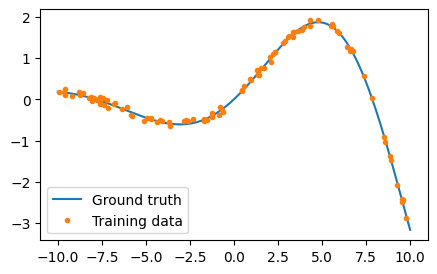

In [56]:
# Ground truth
f = lambda x: np.sin(0.4*x)*(np.exp(x/7.0))

# Random sampling
np.random.seed(0)

n = 100
xdata = 20*np.random.rand(n)-10
ydata = f(xdata)

noise = 0.1*(2*np.random.rand(n) - 1)
ydata += noise

# Visualization
x = np.linspace(-10, 10, 1000)
y = f(x)
plt.figure(figsize = (5, 3))
plt.plot(x, y, label = 'Ground truth')
plt.plot(xdata, ydata, '.', label = 'Training data')
plt.legend()
plt.show()

In [57]:
xdata.shape, ydata.shape

((100,), (100,))

In [58]:
# Transfering from numpy arrays to torch tensors
xdata = dv.tensor(xdata).reshape(-1, 1)
ydata = dv.tensor(ydata).reshape(-1, 1)

In [59]:
xdata.shape, ydata.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

In [60]:
from dlroms.roms import DFNN

# Neural network architecture
phi = Dense(1, 5, gelu) + Dense(5, 5, gelu) + Dense(5, 1, None)

dnn = DFNN(phi)  # Wrapping the architecture with a "trainable object"
dnn.to(dv)

In [61]:
def loss(true, pred):
    return (true-pred).pow(2).sum(axis = -1).mean()

def error(true, pred):
    return (true-pred).abs().sum(axis = -1).mean()

n = len(xdata)
noptim = int(0.5*n)
nvalid = int(0.2*n)

dnn.He() # random initialization
dnn.train(xdata, ydata, ntrain = noptim + nvalid, nvalid = nvalid, epochs = 100, loss = loss, error = error)

		Train		Valid		Test
Epoch 36:	2.75e-02	6.88e-02	6.42e-02.

>> ETA: 15.85s.


Training complete. Elapsed time: 8.84 seconds.


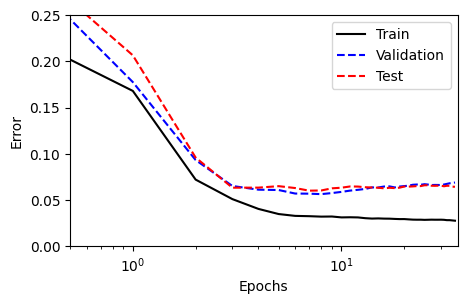

In [62]:
# Diagnostic
n_epochs = len(dnn.errors['Train'])
plt.figure(figsize = (5, 3))
plt.semilogx(dnn.errors['Train'], '-k', label = 'Train')
plt.semilogx(dnn.errors['Validation'], '--b', label = 'Validation')
plt.semilogx(dnn.errors['Test'], '--r', label = 'Test')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.axis([0.5, n_epochs, 0, 0.25])
plt.legend()
plt.show()

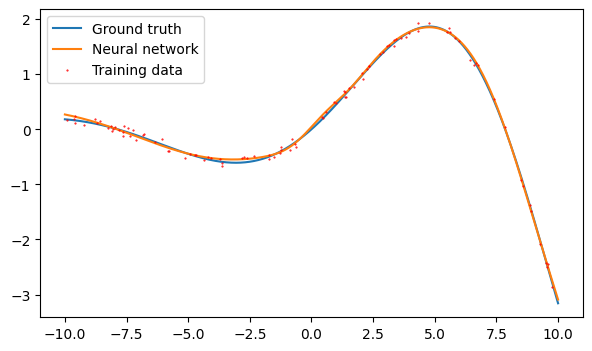

In [63]:
# Freezing and evaluation
dnn.freeze()

plt.figure(figsize = (7, 4))
plt.plot(x, y, label = 'Ground truth')

y_network = dnn(dv.tensor(x).reshape(-1, 1)).reshape(-1).cpu().numpy()

plt.plot(x, y_network, label = 'Neural network')

plt.plot(xdata.cpu().numpy(), ydata.cpu().numpy(), '.r', label = 'Training data', markersize = 1)
plt.legend()
plt.show()

In [64]:
## NB: Models can be saved using .save(...) and later loaded using .load(...)!
dnn.save("my_nn")

In [65]:
error(ydata, dnn(xdata))

tensor(0.0453, device='cuda:0')

In [66]:
dnn.unfreeze()
dnn.He()
error(ydata, dnn(xdata))

tensor(4.3832, device='cuda:0', grad_fn=<MeanBackward0>)

In [67]:
dnn.load("my_nn")
error(ydata, dnn(xdata))

tensor(0.0453, device='cuda:0', grad_fn=<MeanBackward0>)

### Hands-on

<mark>**Exercise 1**</mark></br>
We want to learn the map

$$s:(x,y)\mapsto x - y^2$$

by relying on noisy samples $\{(x_i, y_i), z_i\}_{i=1}^{N}$, where $z_i\approx s(x_i, y_i)$. Implement and train a suitable neural network model using the data provided below. To this end, make sure to split the data between training and testing with a (50+20):30 ratio, the 20% being the portion devoted to the validation set.

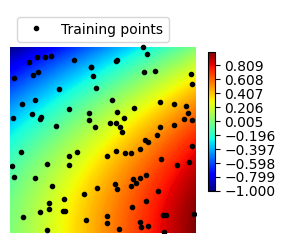

In [68]:
mesh = fe.unitsquaremesh(50, 50)
Vh = fe.space(mesh, 'CG', 1)
x, y = fe.coordinates(Vh).T
s = lambda x, y: x - y**2

n = 100
np.random.seed(0)
xydata = np.random.rand(n, 2)
sdata = s(xydata[:, 0], xydata[:, 1])

noise = 0.02*(2*np.random.rand(n) - 1)
sdata += noise

clc()
plt.figure(figsize = (3, 3))
fe.plot(s(x, y), Vh, colorbar = True, shrink = 0.6)
plt.plot(xydata[:, 0], xydata[:, 1], '.k', label = 'Training points')
plt.axis([0, 1, 0, 1.2])
plt.legend(loc = 'upper left')
plt.show()

In [69]:
xydata.shape, sdata.shape

((100, 2), (100,))

In [70]:
xydata[0], sdata[0]

(array([0.5488135 , 0.71518937]), np.float64(0.02978950943490597))

In [71]:
xydata = dv.tensor(xydata)
sdata  = dv.tensor(sdata).reshape(-1, 1)

In [72]:
phi = Dense(2, 30, gelu) + Dense(30, 10, gelu) + Dense(10, 1, None)
dnn = DFNN(phi)
dnn.moveOn(dv)

n = len(xydata)
dnn.He()
dnn.train(xydata, sdata, ntrain = int(0.70*n), nvalid = int(0.20*n), epochs = 100, loss = loss, error = error)

		Train		Valid		Test
Epoch 100:	8.09e-03	1.12e-02	1.45e-02.

>> ETA: 0.06s.


Training complete. Elapsed time: 6.06 seconds.


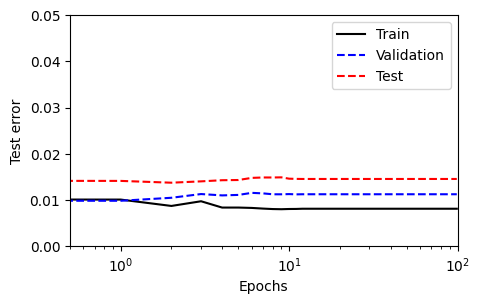

In [73]:
# Diagnostic
n_epochs = len(dnn.errors['Train'])
plt.figure(figsize = (5, 3))
plt.semilogx(dnn.errors['Train'], '-k', label = 'Train')
plt.semilogx(dnn.errors['Validation'], '--b', label = 'Validation')
plt.semilogx(dnn.errors['Test'], '--r', label = 'Test')
plt.xlabel('Epochs')
plt.ylabel('Test error')
plt.axis([0.5, n_epochs, 0, 0.05])
plt.legend()
plt.show()

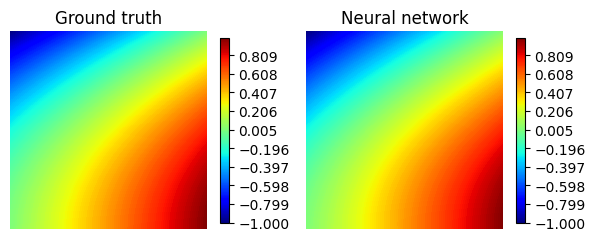

In [74]:
plt.figure(figsize = (7, 3))
plt.subplot(1, 2, 1)
fe.plot(s(x, y), Vh, colorbar = True, vmin = -1, vmax = 1)
plt.title("Ground truth")

plt.subplot(1, 2, 2)
xytensor = dv.tensor(fe.coordinates(Vh))
fe.plot(dnn(xytensor).reshape(-1), Vh, colorbar = True, vmin = -1, vmax = 1)
plt.title("Neural network")

plt.show()

## Convolutional neural networks

Convolutional neural networks are particular architectures tailored for handling high-dimensional inputs, coming in form of *channelled-data* (images in 2D, time series in 1D, etc.). They were introduced to mitigate the number of trainable parameters, as dense layers typically resulted in very complex architectures.

In brief, convolutional layers use a "shared" bias value (instead of a whole vector) and rely on a convolutional kernels rather than weight matrices (the action is still linear, but it can be described by far less parameters).
</br></br>
*Note: differently from dense layers, convolutional layers can operate on inputs with different dimensions, as long as their shapes are consistent.*

In [75]:
from dlroms.dnns import Conv2D

L = Conv2D(window = 2, channels = (1, 1))
print(L.w())
print()
print(L.b())

Parameter containing:
tensor([[[[-0.2870, -0.4877],
          [ 0.2985, -0.1974]]]], requires_grad=True)

Parameter containing:
tensor([0.0042], requires_grad=True)


In [76]:
# NB: 2D convolutional layers expect inputs to be of the form Nsamples x Nchannels x Xdim x Ydim
from dlroms.dnns import Reshape

nn = Reshape(1, 10, 10) + Conv2D(window = 2, channels = (1, 4)) + Conv2D(window = 2, channels = (4, 2)) + Reshape(-1)
nn.dims()

'100 -> (1, 10, 10) -> (4, 9, 9) -> (2, 8, 8) -> 128'

### Hands-on

The following piece of code grants you access to a dataset $\{\mathbf{D}_{i}, \mathbf{c}_{i}\}_{i=1}^{N}$ where, for each $i=1,\dots,N$,

- $\mathbf{D}_{i}$ is a $51\times51$ matrix representing an image of a circle within the unit square;

- $\mathbf{c}_{i}\in\mathbb{R}^{2}$ is the center of the circle in $\mathbf{D}_{i}$.

In [77]:
import gdown
gdown.download(id = "14vdopFVYG-TPjL7fyfhg482FslesZ2x2", output = "circles.npz")
dataset = np.load("circles.npz")

D, c = dataset["images"], dataset["centers"]

Downloading...
From: https://drive.google.com/uc?id=14vdopFVYG-TPjL7fyfhg482FslesZ2x2
To: /content/circles.npz
100%|██████████| 6.25M/6.25M [00:00<00:00, 275MB/s]


Examples extracted from the data at hand:



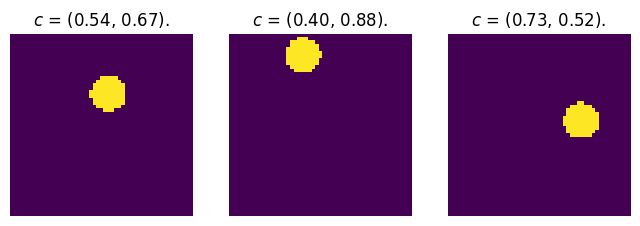

In [78]:
print("Examples extracted from the data at hand:\n")
plt.figure(figsize = (8, 3))
for i, k in enumerate([0, -1, 5]):
  plt.subplot(1,3,i+1)
  plt.imshow(D[k], origin = 'lower')
  plt.axis("off")
  plt.title("$c$ = (%.2f, %.2f)." % tuple(c[k]))

<mark>**Exercise 2**</mark></br>
Learn the map $\mathbf{D}\mapsto\mathbf{c}$ using a suitable neural network model. To this end, use a combination of convolutional and dense layers.
</br></br>
*Side question:* at a continuous level, the ground truth relationship between input and output can be viewed as a map $\mathcal{F}:L^{1}(\Omega)\to\mathbb{R}^{2}$, with $\Omega=(0,1)^2$. Can you provide an analytic expression for $\mathcal{F}$? What is the regularity of $\mathcal{F}$?

In [79]:
D, c = dv.tensor(D), dv.tensor(c)

In [123]:
from dlroms.dnns import Conv2D, Reshape
psi = (Reshape(1, 51, 51) +
       Conv2D(window = 5, channels = (1, 2), stride = 2, activation = gelu) +
       Conv2D(window = 5, channels = (2, 4), stride = 2, activation = gelu) +
       Conv2D(window = 5, channels = (4, 4), stride = 2, activation = gelu) +
       Reshape(-1) +
       Dense(36, 2, None))

psi.to(dv)
psi.dims()

'2601 -> (1, 51, 51) -> (2, 24, 24) -> (4, 10, 10) -> (4, 3, 3) -> 36 -> 2'

In [124]:
def loss(true, pred):
    return (true-pred).pow(2).sum(axis = -1).mean()

def error(true, pred):
    return (true-pred).abs().sum(axis = -1).mean()

In [125]:
cnn = DFNN(psi)

N = len(D)
cnn.He()
cnn.train(D, c, ntrain = int(0.8*N), nvalid = int(0.1*N), epochs = 100, loss = loss,  error = error)

		Train		Valid		Test
Epoch 71:	1.22e-02	5.99e-02	5.76e-02.

>> ETA: 8.46s.


Training complete. Elapsed time: 20.03 seconds.


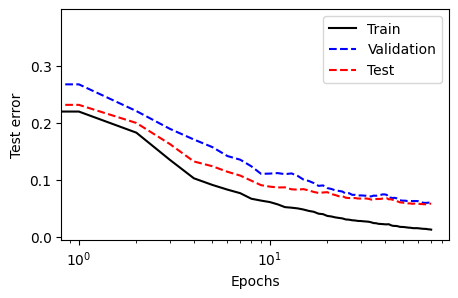

In [126]:
cnn.freeze()
n_epochs = len(cnn.errors['Train'])
plt.figure(figsize = (5, 3))
plt.semilogx(cnn.errors['Train'], '-k', label = 'Train')
plt.semilogx(cnn.errors['Validation'], '--b', label = 'Validation')
plt.semilogx(cnn.errors['Test'], '--r', label = 'Test')
plt.xlabel('Epochs')
plt.ylabel('Test error')
plt.legend()
plt.show()

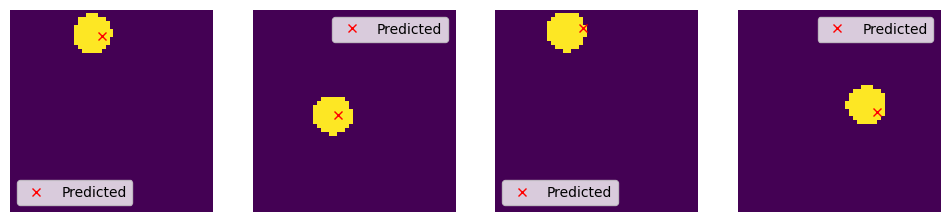

In [127]:
predicted = cnn(D).cpu().numpy()
plt.figure(figsize = (12, 3))
for j in range(4):
    image = D[-j-1].cpu().numpy()
    center = 51*predicted[-j-1]
    plt.subplot(1,4,j+1)
    plt.imshow(image, origin = 'lower')
    plt.plot(*center, 'x', color = 'red', label = 'Predicted')
    plt.legend()
    plt.axis("off")

<mark>**Exercise 3**</mark></br>
The following piece of code gives you access to another dataset, analogous to the previous one, where the "circles" have been substituted with "squares". Test your previous model (the one trained in Ex. 2) on this new dataset: does it work?

In [128]:
gdown.download(id = "1-2G3b7hCCeqNE3Kr6oPuNW9_VX1hdWgV", output = "squares.npz")
squares_dataset = np.load("squares.npz")
squares, centers = squares_dataset["images"], squares_dataset["centers"]

Downloading...
From: https://drive.google.com/uc?id=1-2G3b7hCCeqNE3Kr6oPuNW9_VX1hdWgV
To: /content/squares.npz
100%|██████████| 6.25M/6.25M [00:00<00:00, 163MB/s]


In [129]:
squares, centers = dv.tensor(squares), dv.tensor(centers)

In [130]:
error(centers, cnn(squares))

tensor(0.0797, device='cuda:0')

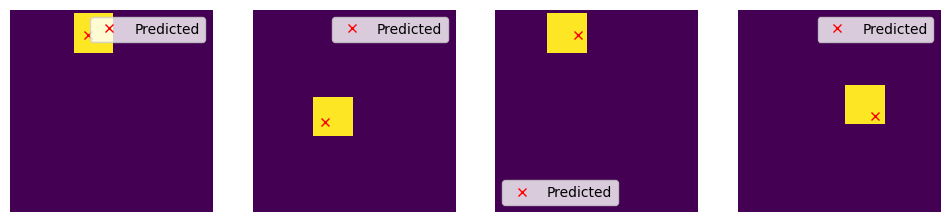

In [131]:
predicted = cnn(squares).cpu().numpy()
plt.figure(figsize = (12, 3))
for j in range(4):
    image = squares[-j-1].cpu().numpy()
    center = 51*predicted[-j-1]
    plt.subplot(1,4,j+1)
    plt.imshow(image, origin = 'lower')
    plt.plot(*center, 'x', color = 'red', label = 'Predicted')
    plt.legend()
    plt.axis("off")